In [ ]:
from google.colab import files
uploaded = files.upload()

Saving survey.csv to survey (2).csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

# Replace the filename with your actual uploaded file name
df = pd.read_csv('survey.csv')  # change if different name

# Preview the data
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


Q1. What demographic factors (age, gender, self‑employment) are most associated with seeking treatment?

In [ ]:
# Load and subset relevant columns
cols = ['Age', 'Gender', 'self_employed', 'treatment']
df_demo = df[cols].copy()

# Clean Gender
df_demo['Gender'] = df_demo['Gender'].str.lower()
df_demo['Gender'] = df_demo['Gender'].apply(
    lambda x: 'male' if 'm' in x else ('female' if 'f' in x else 'other'))

# Filter valid entries
df_demo = df_demo[df_demo['Gender'].isin(['male', 'female'])]
df_demo = df_demo[df_demo['self_employed'].isin(['Yes', 'No'])]
df_demo = df_demo[df_demo['treatment'].isin(['Yes', 'No'])]
df_demo = df_demo[(df_demo['Age'] >= 16) & (df_demo['Age'] <= 100)]

# Binary column for treatment
df_demo['treatment_binary'] = df_demo['treatment'].map({'Yes': 1, 'No': 0})

# Age group
df_demo['age_group'] = pd.cut(df_demo['Age'], bins=[15, 25, 35, 45, 100],
                              labels=['16-25', '26-35', '36-45', '46+'])

df_demo.head()

,Age,Gender,self_employed,treatment,treatment_binary,age_group
18,46,male,Yes,No,0,46+
19,36,male,Yes,No,0,36-45
20,29,male,No,Yes,1,26-35
21,31,male,Yes,No,0,26-35
22,46,male,No,Yes,1,46+


/tmp/ipython-input-10-3260735706.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_demo, x='Gender', y='treatment_binary', ci=None)


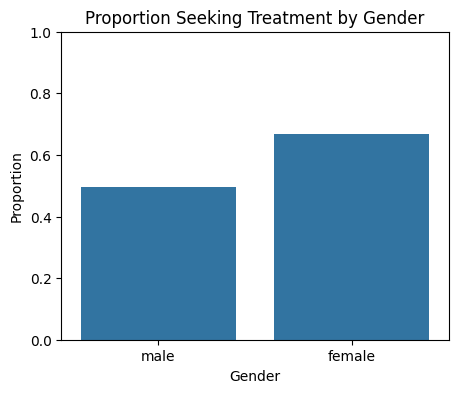

/tmp/ipython-input-10-3260735706.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_demo, x='self_employed', y='treatment_binary', ci=None)


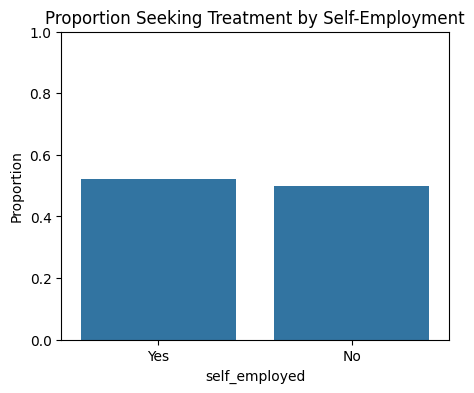

/tmp/ipython-input-10-3260735706.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_demo, x='age_group', y='treatment_binary', ci=None)


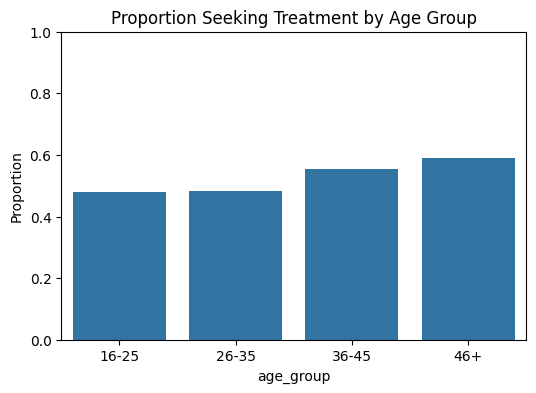

In [ ]:
# Bar Plot: Gender vs Treatment
plt.figure(figsize=(5, 4))
sns.barplot(data=df_demo, x='Gender', y='treatment_binary', ci=None)
plt.title('Proportion Seeking Treatment by Gender')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.show()

# Bar Plot: Self-Employment vs Treatment
plt.figure(figsize=(5, 4))
sns.barplot(data=df_demo, x='self_employed', y='treatment_binary', ci=None)
plt.title('Proportion Seeking Treatment by Self-Employment')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.show()

# Bar Plot: Age Group vs Treatment
plt.figure(figsize=(6, 4))
sns.barplot(data=df_demo, x='age_group', y='treatment_binary', ci=None)
plt.title('Proportion Seeking Treatment by Age Group')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.show()


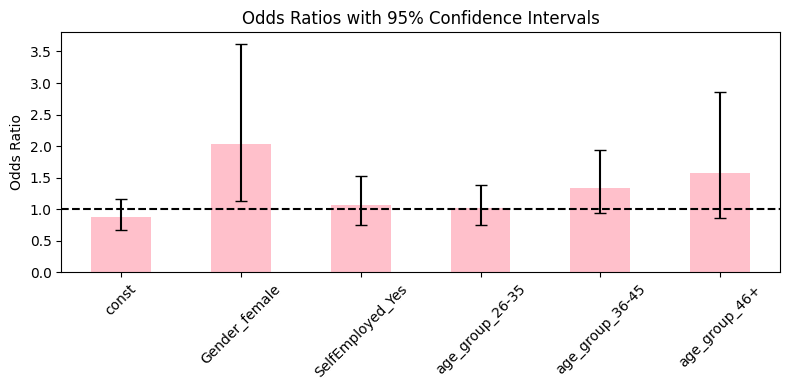

In [ ]:
# Make a copy of the cleaned dataset
df_lr = df_demo.copy()

# Convert categorical values to binary (1 or 0)
df_lr['Gender_female'] = (df_lr['Gender'] == 'female').astype(int)
df_lr['SelfEmployed_Yes'] = (df_lr['self_employed'] == 'Yes').astype(int)

# Turn age groups into dummy variables (skip the first group to avoid duplication)
df_lr = pd.get_dummies(df_lr, columns=['age_group'], drop_first=True)

# Select features (X) and target (y)
X = df_lr[['Gender_female', 'SelfEmployed_Yes',
           'age_group_26-35', 'age_group_36-45', 'age_group_46+']].astype(float)
X = sm.add_constant(X)  # Add intercept
y = df_lr['treatment_binary'].astype(int)

# Fit logistic regression model
model = sm.Logit(y, X).fit(disp=0)

# Calculate odds ratios and 95% confidence intervals
odds = np.exp(model.params).round(3)
conf = np.exp(model.conf_int()).round(3)
conf.columns = ['CI Lower', 'CI Upper']

# Combine into a single table
or_table = pd.concat([odds.rename('Odds Ratio'), conf], axis=1)

# Plot the odds ratios with error bars
plt.figure(figsize=(8, 4))
or_table['Odds Ratio'].plot(kind='bar',
                            yerr=[or_table['Odds Ratio'] - conf['CI Lower'],
                                  conf['CI Upper'] - or_table['Odds Ratio']],
                            capsize=4, color='pink')
plt.axhline(y=1, linestyle='--', color='black')
plt.title("Odds Ratios with 95% Confidence Intervals")
plt.ylabel("Odds Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
print(model.pvalues)


const               0.365912
Gender_female       0.016513
SelfEmployed_Yes    0.697268
age_group_26-35     0.907232
age_group_36-45     0.109924
age_group_46+       0.138526
dtype: float64


Q2. Does working remotely or in a tech‑only company change the probability of accessing employer mental‑health support?

In [ ]:
cols = ['remote_work', 'tech_company', 'benefits']
df = df[cols].copy()

# Focus on clear Yes/No responses; drop anything else (e.g. “Sometimes”, “Don’t know”)
yes_no = {'Yes', 'No'}
df = df[(df['remote_work'].isin(yes_no)) &
        (df['tech_company'].isin(yes_no)) &
        (df['benefits'].isin(yes_no))]

# Quick look
df.head()

,remote_work,tech_company,benefits
0,No,Yes,Yes
2,No,Yes,No
3,No,Yes,No
4,Yes,Yes,Yes
5,No,Yes,Yes


z = 3.51,  p = 0.0005


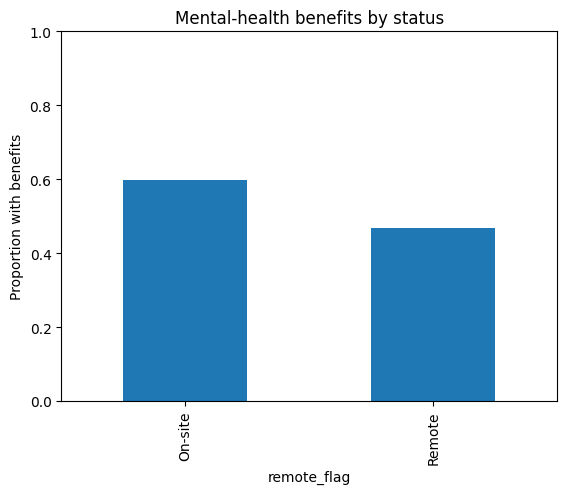

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# prepare counts
remote = df.copy()
remote['remote_flag'] = (remote['remote_work'] == 'Yes')   # True = remote

# Number who receive benefits in each group
successes = remote.groupby('remote_flag')['benefits'].apply(lambda s: (s == 'Yes').sum())
# Number of people in each group
totals    = remote.groupby('remote_flag')['benefits'].size()

# two‑proportion z‑test
z_stat, p_val = proportions_ztest(count=successes, nobs=totals, alternative='two-sided')
print(f'z = {z_stat:.2f},  p = {p_val:.4f}')

# grouped bar plot
prop = (successes / totals).rename({True:'Remote', False:'On‑site'})

prop.plot(kind='bar')
plt.ylabel('Proportion with benefits')
plt.title('Mental‑health benefits by status')
plt.ylim(0, 1)
plt.show()


z = 3.06,  p = 0.0022


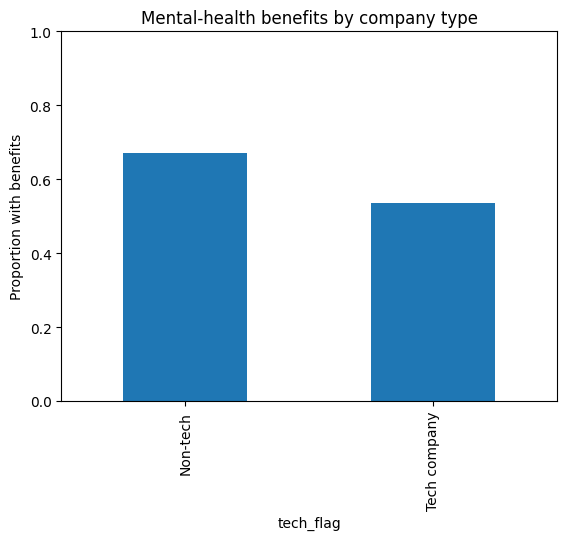

In [ ]:
tech = df.copy()
tech['tech_flag'] = (tech['tech_company'] == 'Yes')   # True = tech‑only firm

successes = tech.groupby('tech_flag')['benefits'].apply(lambda s: (s == 'Yes').sum())
totals    = tech.groupby('tech_flag')['benefits'].size()

# two‑proportion z‑test
z_stat, p_val = proportions_ztest(count=successes, nobs=totals, alternative='two-sided')
print(f'z = {z_stat:.2f},  p = {p_val:.4f}')

# grouped bar plot
prop = (successes / totals).rename({True:'Tech company', False:'Non‑tech'})

prop.plot(kind='bar')
plt.ylabel('Proportion with benefits')
plt.title('Mental‑health benefits by company type')
plt.ylim(0, 1)
plt.show()


Q3. How does employer size (number of employees) affect employees’ perception of support and actual treatment behaviour?

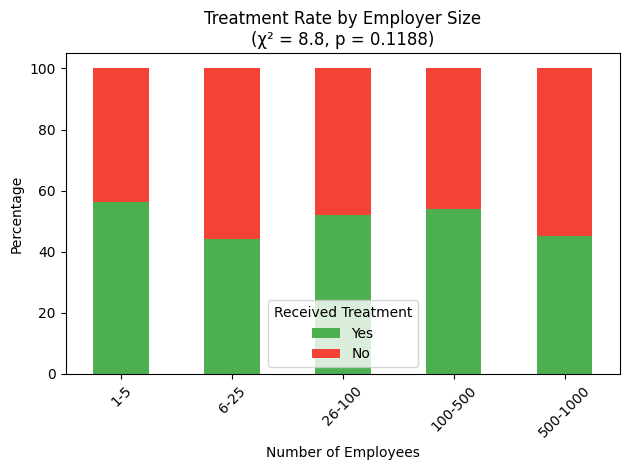

/tmp/ipython-input-24-410883393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")


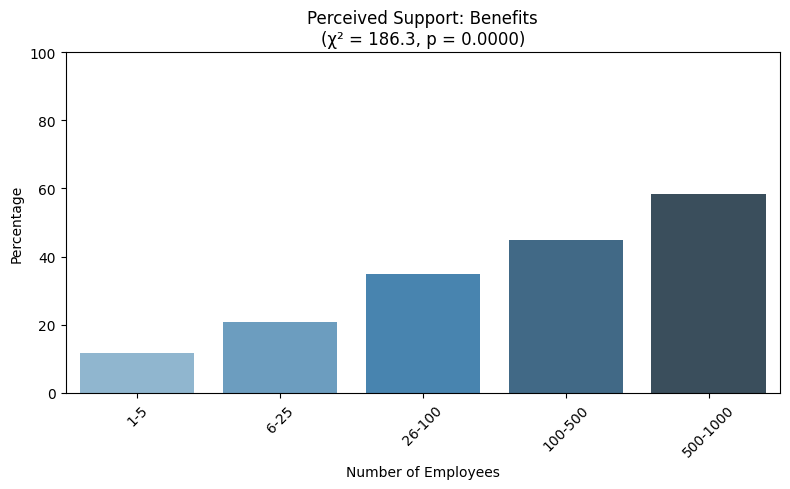

/tmp/ipython-input-24-410883393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")


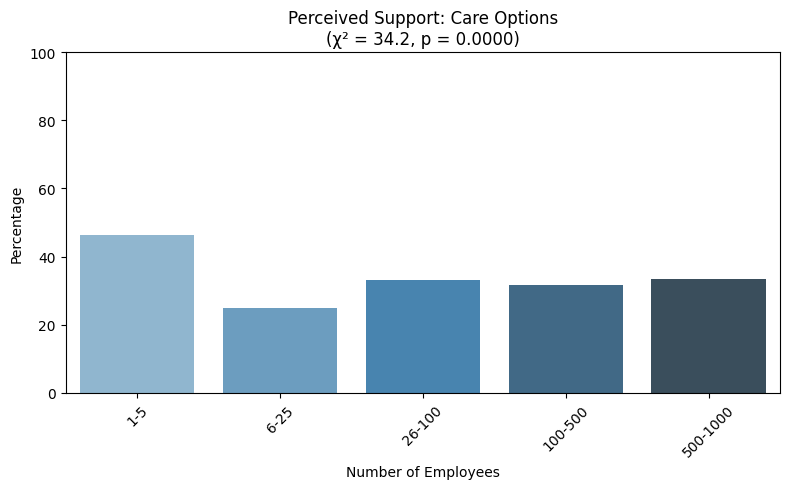

/tmp/ipython-input-24-410883393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")


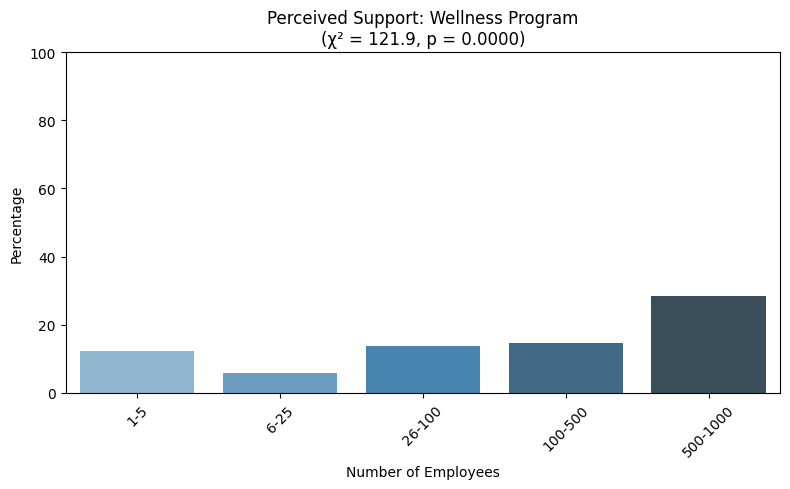

/tmp/ipython-input-24-410883393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")


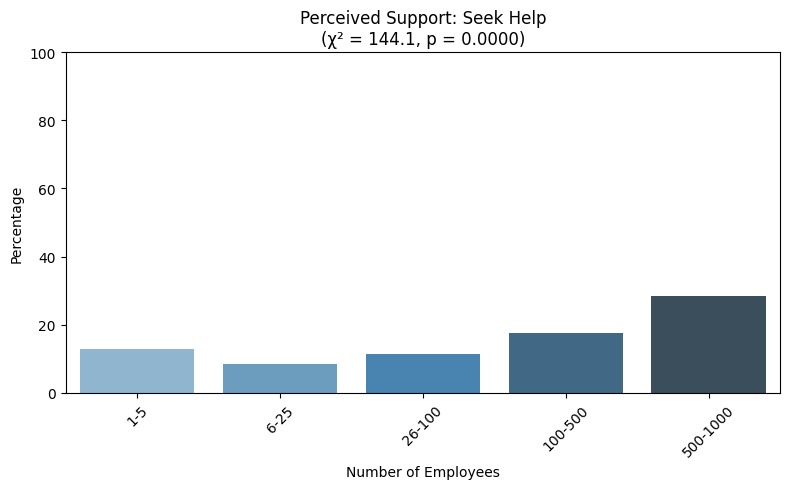

/tmp/ipython-input-24-410883393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")


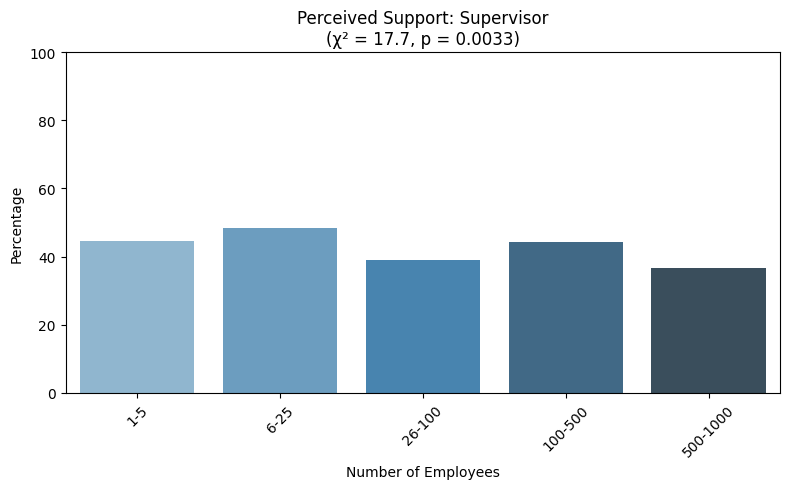

/tmp/ipython-input-24-410883393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")


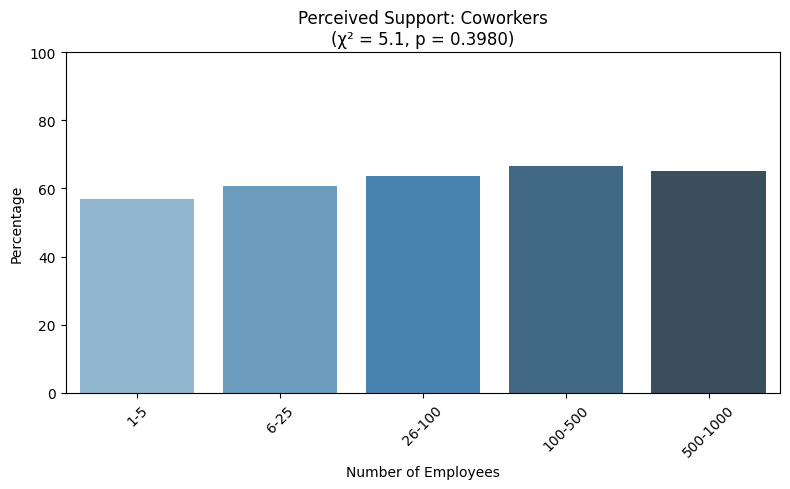

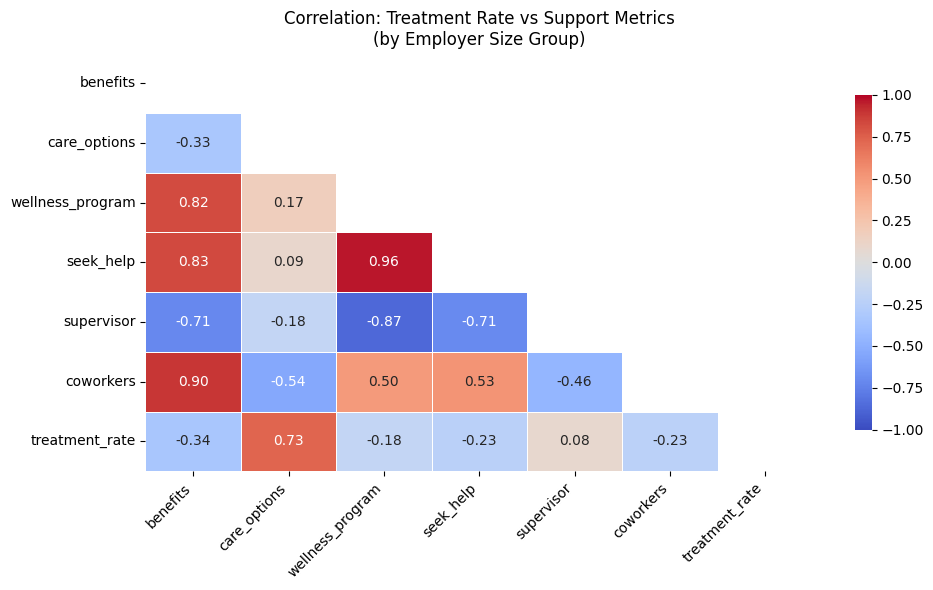

In [ ]:
from scipy.stats import chi2_contingency

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^a-z0-9_]', '', regex=True)

# Define employer size order
employer_order = ["1-5", "6-25", "26-100", "100-500", "500-1000"]
df['no_employees'] = df['no_employees'].str.strip()

# Treatment Rate Analysis with Chi-Square Test
treatment_contingency = pd.crosstab(df['no_employees'], df['treatment'])
chi2, p, dof, _ = chi2_contingency(treatment_contingency)

treatment_by_size = (
    df.groupby('no_employees')['treatment']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
).reindex(employer_order)[['Yes', 'No']]

# Plot with statistical significance annotation
ax = treatment_by_size.plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'])
plt.title(f"Treatment Rate by Employer Size\n(χ² = {chi2:.1f}, p = {p:.4f})")
plt.ylabel("Percentage")
plt.xlabel("Number of Employees")
plt.xticks(rotation=45)
plt.legend(title="Received Treatment")
plt.tight_layout()
plt.show()

#  Support Metrics Analysis with Chi-Square Tests
support_columns = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'supervisor', 'coworkers']
support_labels = {
    'benefits': 'Yes',
    'care_options': 'Yes',
    'wellness_program': 'Yes',
    'seek_help': 'Yes',
    'supervisor': 'Yes',
    'coworkers': 'Some of them'
}

#  data for heatmap
heatmap_data = pd.DataFrame(index=employer_order)

for col, positive_label in support_labels.items():
    # Chi-square test for each support metric
    df[f'{col}_positive'] = df[col].apply(lambda x: 1 if x == positive_label else 0)
    contingency = pd.crosstab(df['no_employees'], df[f'{col}_positive'])
    chi2, p, dof, _ = chi2_contingency(contingency)

    # Get support rates
    support_data = (
        df.groupby('no_employees')[col]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0) * 100
    )

    if positive_label in support_data.columns:
        support_plot = support_data.reindex(employer_order)[positive_label]
        heatmap_data[col] = support_plot  # Add to heatmap data

        # Plot with statistical significance annotation
        plt.figure(figsize=(8, 5))
        sns.barplot(x=support_plot.index, y=support_plot.values, palette="Blues_d")
        plt.title(f"Perceived Support: {col.replace('_', ' ').title()}\n(χ² = {chi2:.1f}, p = {p:.4f})")
        plt.ylabel("Percentage")
        plt.xlabel("Number of Employees")
        plt.ylim(0, 100)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Correlation Heatmap (Treatment vs Support Metrics)
heatmap_data['treatment_rate'] = treatment_by_size['Yes']

plt.figure(figsize=(10, 6))
corr_matrix = heatmap_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=.5,
            cbar_kws={"shrink": 0.8})

plt.title("Correlation: Treatment Rate vs Support Metrics\n(by Employer Size Group)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Q4. Can we accurately classify whether an individual will seek treatment based on their survey answers?

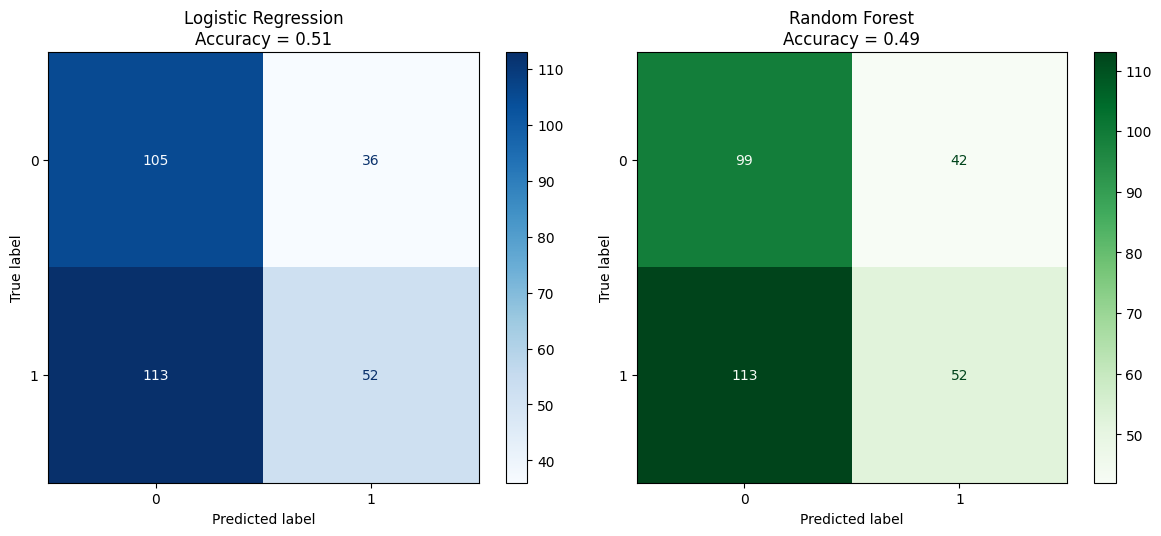

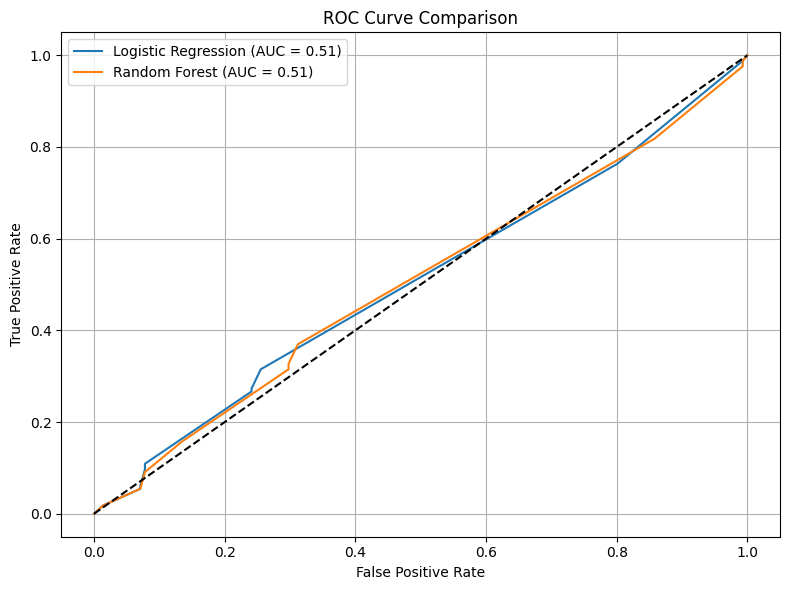

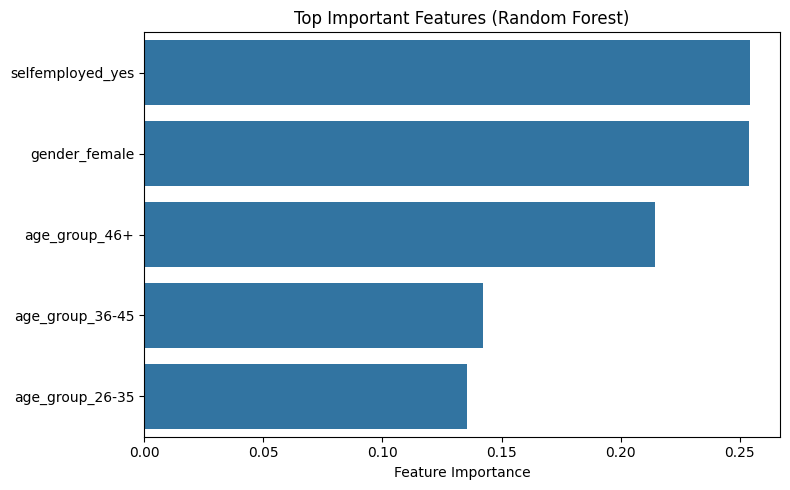

Logistic Regression Accuracy: 0.513, AUC: 0.507
Random Forest Accuracy: 0.493, AUC: 0.506


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split


df = pd.read_csv("survey.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^a-z0-9_]', '', regex=True)


cols = ['age', 'gender', 'self_employed', 'treatment']
df_demo = df[cols].copy()

# Clean and standardize gender
df_demo['gender'] = df_demo['gender'].str.lower().str.strip()
df_demo['gender'] = df_demo['gender'].apply(
    lambda x: 'male' if 'm' in x else ('female' if 'f' in x else 'other'))

# Filter valid entries
df_demo = df_demo[df_demo['gender'].isin(['male', 'female'])]
df_demo = df_demo[df_demo['self_employed'].isin(['Yes', 'No'])]
df_demo = df_demo[df_demo['treatment'].isin(['Yes', 'No'])]
df_demo = df_demo[(df_demo['age'] >= 16) & (df_demo['age'] <= 100)]

# Create binary label for treatment
df_demo['treatment_binary'] = df_demo['treatment'].map({'Yes': 1, 'No': 0})

# Age group bins
df_demo['age_group'] = pd.cut(
    df_demo['age'],
    bins=[15, 25, 35, 45, 100],
    labels=['16-25', '26-35', '36-45', '46+']
)

# Encode features
df_lr = df_demo.copy()
df_lr['gender_female'] = (df_lr['gender'] == 'female').astype(int)
df_lr['selfemployed_yes'] = (df_lr['self_employed'] == 'Yes').astype(int)
df_lr = pd.get_dummies(df_lr, columns=['age_group'], drop_first=True)

# Define features and target
X = df_lr[['gender_female', 'selfemployed_yes',
           'age_group_26-35', 'age_group_36-45', 'age_group_46+']].astype(float)
y = df_lr['treatment_binary'].astype(int)


#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


# Train Models

lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)


#  Predictions

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]


#  Accuracy & Confusion Matrices

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=axs[0], cmap='Blues')
axs[0].set_title(f'Logistic Regression\nAccuracy = {lr_acc:.2f}')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axs[1], cmap='Greens')
axs[1].set_title(f'Random Forest\nAccuracy = {rf_acc:.2f}')

plt.tight_layout()
plt.show()

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Feature Importance (Random Forest)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
top_features = [X.columns[i] for i in indices]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=top_features)
plt.title('Top Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()


#  Summary
print(f"Logistic Regression Accuracy: {lr_acc:.3f}, AUC: {lr_auc:.3f}")
print(f"Random Forest Accuracy: {rf_acc:.3f}, AUC: {rf_auc:.3f}")
